# 4. Improved Deep Learning Pipeline

Previous models peaked at ~50% accuracy due to:
- No input normalisation
- Excessive zero-padding (5s for 2–3s cycles)
- Learning rate too high (1e-3)
- Weak augmentation

This notebook applies targeted fixes:
1. Per-sample spectrogram standardisation (zero mean, unit variance)
2. Reduced cycle duration (4s → better signal-to-noise ratio)
3. Audio-level augmentation (noise injection, time shift, pitch perturbation)
4. Lower learning rate (3e-4) with cosine annealing
5. Mixup training for regularisation
6. Increased early stopping patience (15 epochs)

In [1]:
import sys
sys.path.append(r"E:\GitHub\lung-sound-classification")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import librosa
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight

from src.config import *
from src.data_loader import load_cycle_audio, patient_split
from src.evaluate import (
    evaluate_predictions, plot_confusion_matrix,
    plot_training_curves, compare_models, get_device
)

device = get_device()
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 4.1 Rebuild Dataset with Shorter Duration
The median cycle duration is ~2.3 seconds. Padding to 5 seconds fills nearly half the spectrogram with silence, which confuses the model. We reduce to **4 seconds** — long enough to capture 95% of cycles without excessive padding.

In [2]:
cycle_df = pd.read_csv(DATA_DIR / 'cycle_dataset.csv')
cycle_df['label'] = cycle_df['label'].astype(int)

# Check duration coverage
for dur in [3, 4, 5]:
    pct = (cycle_df['duration'] <= dur).mean() * 100
    print(f"Cycles <= {dur}s: {pct:.1f}%")

train_df, val_df, test_df = patient_split(cycle_df)
print(f"\nTrain: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Cycles <= 3s: 64.8%
Cycles <= 4s: 88.5%
Cycles <= 5s: 96.6%
Split sizes — Train: 3809, Val: 1386, Test: 1703
Unique patients — Train: 81, Val: 19, Test: 26

Train: 3809, Val: 1386, Test: 1703


## 4.2 Audio Augmentation
For small medical datasets, augmentation is critical. We apply transformations at the **audio level** (before spectrogram conversion) to create realistic variations:

- **Noise injection** — adds low-level Gaussian noise, simulating recording conditions
- **Time shift** — randomly shifts audio forward/backward, simulating capture timing
- **Pitch perturbation** — slight pitch changes via resampling, simulating vocal tract variation
- **Volume scaling** — random gain changes, simulating microphone distance

In [3]:
NEW_CYCLE_DURATION = 4.0  # seconds (reduced from 5)
NEW_TARGET_LEN = int(NEW_CYCLE_DURATION * SAMPLE_RATE)


def augment_audio(y, sr=SAMPLE_RATE):
    """Apply random audio augmentations."""
    # Noise injection
    if np.random.random() > 0.5:
        noise_amp = np.random.uniform(0.001, 0.015)
        noise = np.random.normal(0, noise_amp, len(y))
        y = y + noise

    # Time shift (up to 0.3s either direction)
    if np.random.random() > 0.5:
        shift = int(np.random.uniform(-0.3, 0.3) * sr)
        y = np.roll(y, shift)
        if shift > 0:
            y[:shift] = 0
        elif shift < 0:
            y[shift:] = 0

    # Volume scaling
    if np.random.random() > 0.5:
        gain = np.random.uniform(0.7, 1.3)
        y = y * gain

    # Pitch perturbation (small)
    if np.random.random() > 0.3:
        rate = np.random.uniform(0.9, 1.1)
        y_stretched = librosa.resample(y, orig_sr=sr, target_sr=int(sr * rate))
        if len(y_stretched) >= len(y):
            y = y_stretched[:len(y)]
        else:
            y_padded = np.zeros(len(y))
            y_padded[:len(y_stretched)] = y_stretched
            y = y_padded

    return y.astype(np.float32)


def make_spectrogram(y, sr=SAMPLE_RATE):
    """Convert waveform to normalised log-mel spectrogram."""
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)

    # Per-sample normalisation (zero mean, unit variance)
    mean = log_mel.mean()
    std = log_mel.std()
    if std > 0:
        log_mel = (log_mel - mean) / std
    else:
        log_mel = log_mel - mean

    return log_mel


class LungSoundDataset(Dataset):
    """
    On-the-fly spectrogram generation with audio augmentation.
    Instead of pre-computing spectrograms, we load audio and convert
    each time — enabling augmentation at the waveform level.
    """

    def __init__(self, df, augment=False, cycle_duration=NEW_CYCLE_DURATION):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.target_len = int(cycle_duration * SAMPLE_RATE)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load audio segment
        try:
            duration = row['end'] - row['start']
            y, _ = librosa.load(row['audio_path'], sr=SAMPLE_RATE,
                                offset=row['start'], duration=duration)
        except:
            y = np.zeros(self.target_len, dtype=np.float32)

        # Pad or truncate
        if len(y) < self.target_len:
            y = np.pad(y, (0, self.target_len - len(y)), mode='constant')
        else:
            y = y[:self.target_len]

        # Augment
        if self.augment:
            y = augment_audio(y)

        # Convert to spectrogram
        spec = make_spectrogram(y)

        # To tensor: (1, n_mels, time)
        spec_tensor = torch.FloatTensor(spec).unsqueeze(0)
        label = torch.LongTensor([row['label']])[0]

        return spec_tensor, label


# Test it
test_ds = LungSoundDataset(train_df.head(4), augment=True)
sample_spec, sample_label = test_ds[0]
print(f"Spectrogram shape: {sample_spec.shape}")
print(f"Value range: [{sample_spec.min():.2f}, {sample_spec.max():.2f}]")
print(f"Mean: {sample_spec.mean():.4f}, Std: {sample_spec.std():.4f}")
print(f"Label: {sample_label}")

Spectrogram shape: torch.Size([1, 128, 173])
Value range: [-3.88, 10.29]
Mean: -0.0000, Std: 1.0000
Label: 2


## 4.3 Visualise Raw vs Normalised Spectrograms
Showing the effect of per-sample normalisation — the normalised version has consistent value ranges across samples, which is essential for stable gradient descent.

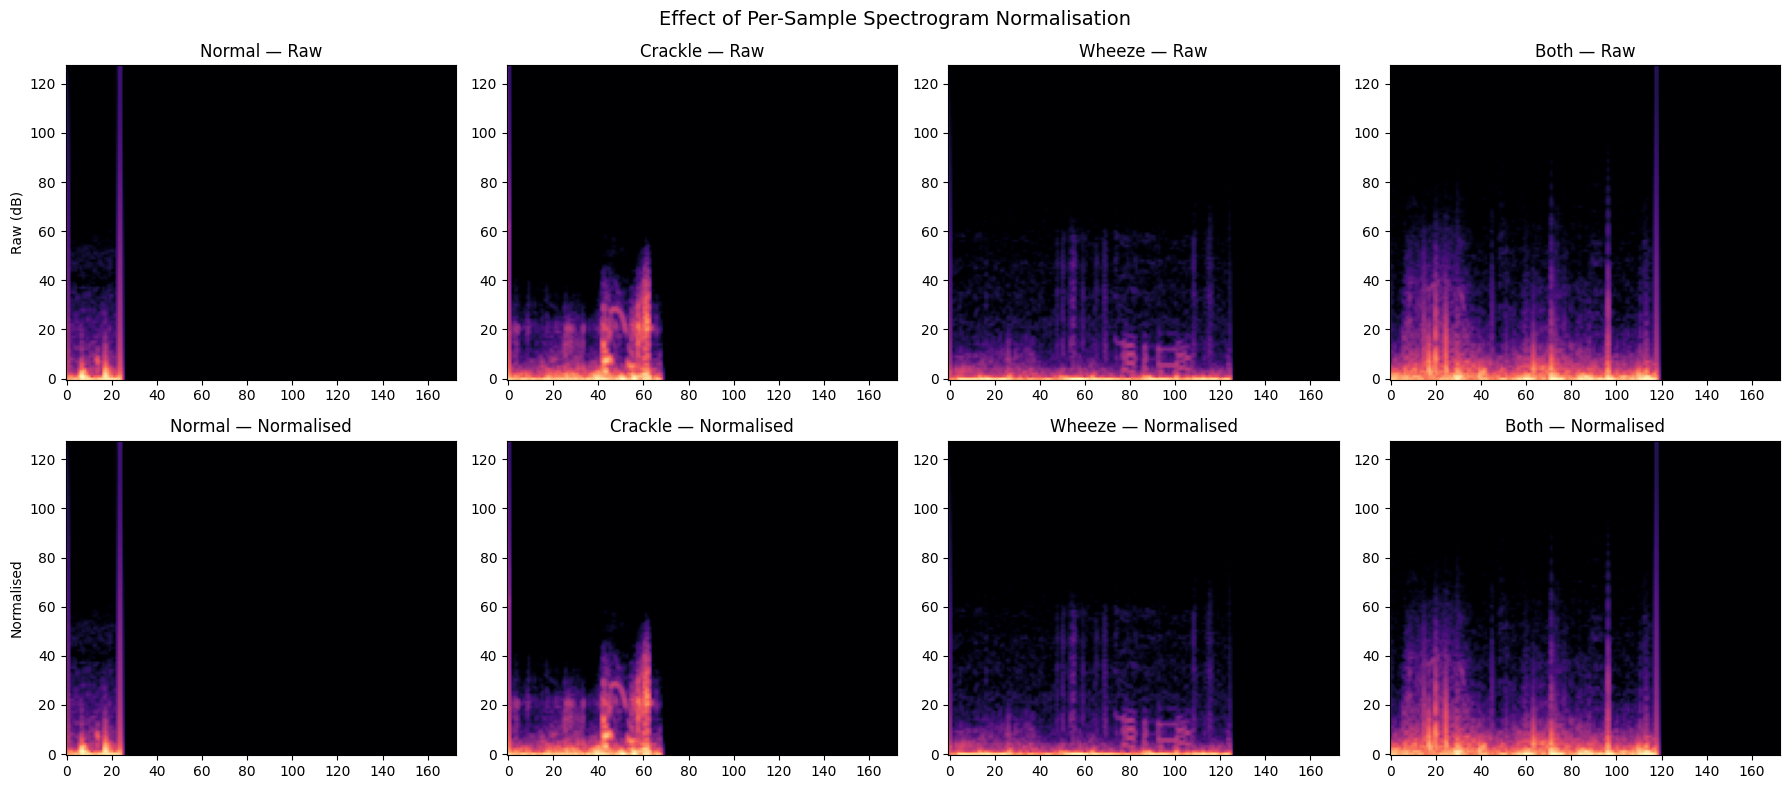

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, label in enumerate(range(4)):
    sample = cycle_df[cycle_df['label'] == label].iloc[0]
    dur = sample['end'] - sample['start']
    y, _ = librosa.load(sample['audio_path'], sr=SAMPLE_RATE,
                        offset=sample['start'], duration=dur)
    if len(y) < NEW_TARGET_LEN:
        y = np.pad(y, (0, NEW_TARGET_LEN - len(y)))
    else:
        y = y[:NEW_TARGET_LEN]

    # Raw
    mel_raw = librosa.power_to_db(
        librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=N_MELS),
        ref=np.max
    )
    axes[0, i].imshow(mel_raw, aspect='auto', origin='lower', cmap='magma')
    axes[0, i].set_title(f'{CYCLE_CLASS_NAMES[label]} — Raw')
    if i == 0:
        axes[0, i].set_ylabel('Raw (dB)')

    # Normalised
    mel_norm = make_spectrogram(y)
    axes[1, i].imshow(mel_norm, aspect='auto', origin='lower', cmap='magma')
    axes[1, i].set_title(f'{CYCLE_CLASS_NAMES[label]} — Normalised')
    if i == 0:
        axes[1, i].set_ylabel('Normalised')

plt.suptitle('Effect of Per-Sample Spectrogram Normalisation', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'normalisation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Create Data Loaders
Using on-the-fly spectrogram generation. Training set gets augmentation, validation and test sets do not. We use `num_workers=0` on Windows (multiprocessing can cause issues).

In [5]:
train_dataset = LungSoundDataset(train_df, augment=True)
val_dataset = LungSoundDataset(val_df, augment=False)
test_dataset = LungSoundDataset(test_df, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Class weights
y_train = train_df['label'].values
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.FloatTensor(class_weights)
print(f"Class weights: {dict(zip(CYCLE_CLASS_NAMES, class_weights.numpy()))}")

# Check a batch
batch_specs, batch_labels = next(iter(train_loader))
print(f"\nBatch shape: {batch_specs.shape}")
print(f"Labels: {batch_labels[:10]}")
print(f"Spec value range: [{batch_specs.min():.2f}, {batch_specs.max():.2f}]")

Class weights: {'Normal': np.float32(0.4219096), 'Crackle': np.float32(1.132283), 'Wheeze': np.float32(1.9394094), 'Both': np.float32(4.328409)}

Batch shape: torch.Size([32, 1, 128, 173])
Labels: tensor([1, 1, 0, 1, 1, 0, 0, 0, 0, 2])
Spec value range: [-6.84, 10.63]


## 4.5 Improved CNN Model
Key changes from previous attempt:
- Added **batch normalisation after every layer** for training stability
- **Dropout scheduling** — lighter in early layers, heavier in later layers
- **Smaller initial kernel** (3×3 instead of 7×7) — better for spectrogram textures

In [6]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.15),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


cnn_model = ImprovedCNN(num_classes=4).to(device)
print(f"Improved CNN parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

Improved CNN parameters: 616,420


## 4.6 Improved Training Loop
Key changes:
- **Learning rate**: 3e-4 (reduced from 1e-3 — more stable convergence)
- **Cosine annealing scheduler**: smoothly reduces LR, avoids getting stuck
- **Mixup training**: blends pairs of samples and labels, powerful regulariser
- **Early stopping patience**: 15 epochs (was 7 — gives the model more time)
- **Gradient clipping**: prevents exploding gradients

In [7]:
def mixup_data(x, y, alpha=0.2):
    """Mixup: blend pairs of samples and labels."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def train_improved(model, train_loader, val_loader, num_epochs=60,
                   lr=3e-4, class_weights=None, model_name="model",
                   patience=15, use_mixup=True):
    """Improved training loop with mixup, cosine annealing, gradient clipping."""
    model = model.to(device)

    if class_weights is not None:
        class_weights = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=num_epochs, eta_min=1e-6)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):
        # ── Train ──
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if use_mixup and np.random.random() > 0.5:
                inputs, y_a, y_b, lam = mixup_data(inputs, labels)
                optimiser.zero_grad()
                outputs = model(inputs)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            else:
                optimiser.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ── Validate ──
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total

        scheduler.step()
        current_lr = optimiser.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Save best (by val loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODELS_DIR / f"{model_name}_best.pt")
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or patience_counter == 0:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
                  f"Train: {train_loss:.4f}/{train_acc:.4f}  "
                  f"Val: {val_loss:.4f}/{val_acc:.4f}  "
                  f"LR: {current_lr:.6f}  "
                  f"{'★ BEST' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\nBest val loss: {best_val_loss:.4f}, Best val acc: {best_val_acc:.4f}")
    return history


# Train CNN
print("=" * 60)
print("  Training Improved CNN")
print("=" * 60)
cnn_history = train_improved(
    cnn_model, train_loader, val_loader,
    num_epochs=60, lr=3e-4, class_weights=class_weights,
    model_name="improved_cnn", patience=15, use_mixup=True
)

  Training Improved CNN
Epoch [  1/60] Train: 1.3755/0.2864  Val: 1.4008/0.3124  LR: 0.000300  ★ BEST
Epoch [  2/60] Train: 1.3689/0.3528  Val: 1.3598/0.4091  LR: 0.000299  ★ BEST
Epoch [  5/60] Train: 1.3315/0.3345  Val: 1.3589/0.2215  LR: 0.000295  ★ BEST
Epoch [  6/60] Train: 1.3267/0.3103  Val: 1.3368/0.2929  LR: 0.000293  ★ BEST
Epoch [  8/60] Train: 1.2910/0.3526  Val: 1.3297/0.3117  LR: 0.000287  ★ BEST
Epoch [  9/60] Train: 1.2715/0.3397  Val: 1.3120/0.3312  LR: 0.000284  ★ BEST
Epoch [ 10/60] Train: 1.2545/0.3581  Val: 1.3088/0.4315  LR: 0.000280  ★ BEST
Epoch [ 14/60] Train: 1.1978/0.4151  Val: 1.2897/0.4661  LR: 0.000262  ★ BEST
Epoch [ 15/60] Train: 1.2004/0.4256  Val: 1.2751/0.4675  LR: 0.000256  ★ BEST
Epoch [ 16/60] Train: 1.1890/0.4277  Val: 1.2654/0.4394  LR: 0.000251  ★ BEST
Epoch [ 17/60] Train: 1.1796/0.4403  Val: 1.2288/0.4473  LR: 0.000245  ★ BEST
Epoch [ 19/60] Train: 1.1498/0.4321  Val: 1.1955/0.4675  LR: 0.000232  ★ BEST
Epoch [ 20/60] Train: 1.1511/0.4421  Val

## 4.7 Evaluate Improved CNN

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\improved_cnn_curves.png


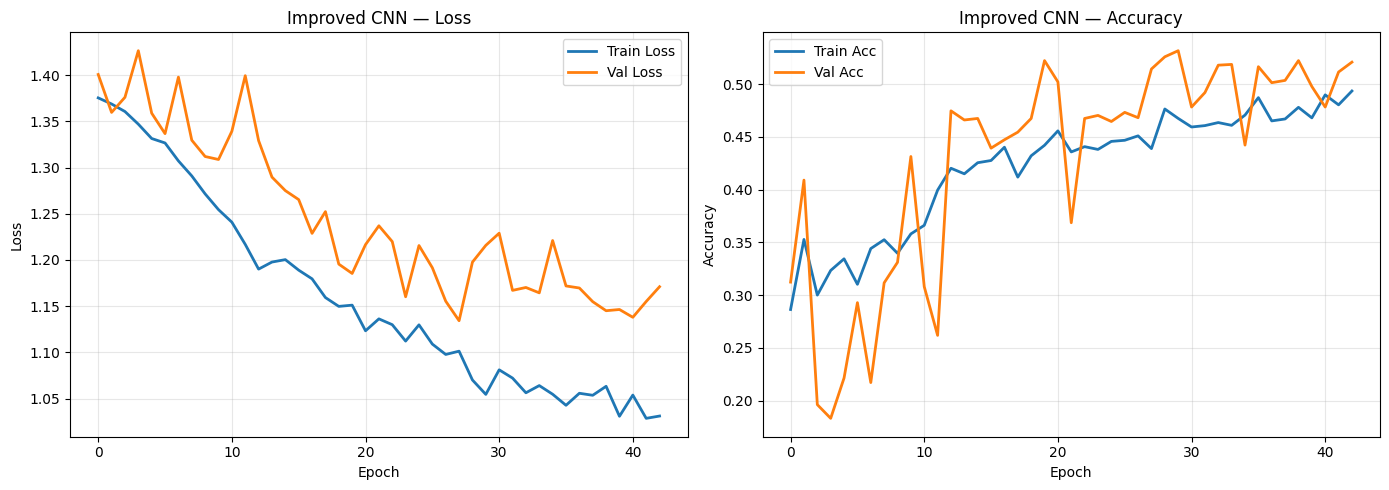


  Improved CNN
  Accuracy:          0.4110
  F1 (macro):        0.3756
  F1 (weighted):     0.4162

              precision    recall  f1-score   support

      Normal       0.63      0.33      0.44       800
     Crackle       0.41      0.57      0.48       517
      Wheeze       0.31      0.28      0.29       224
        Both       0.21      0.48      0.30       162

    accuracy                           0.41      1703
   macro avg       0.39      0.42      0.38      1703
weighted avg       0.48      0.41      0.42      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_improved_cnn.png


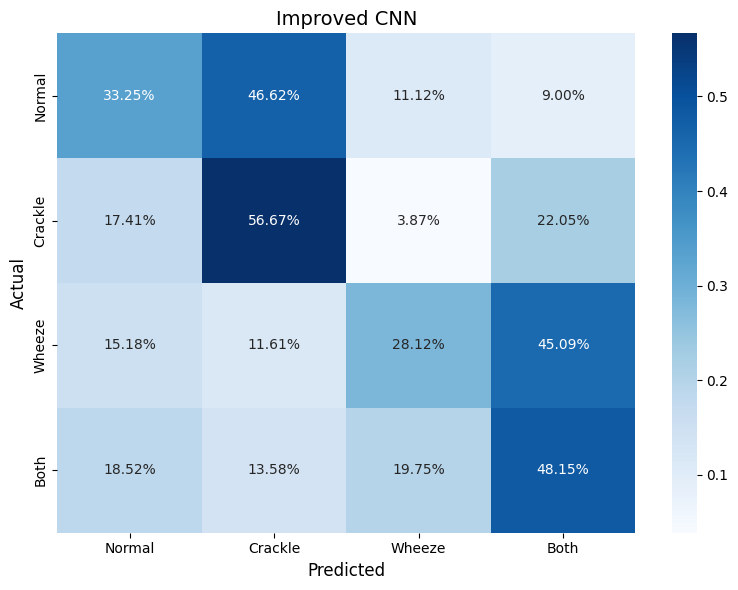

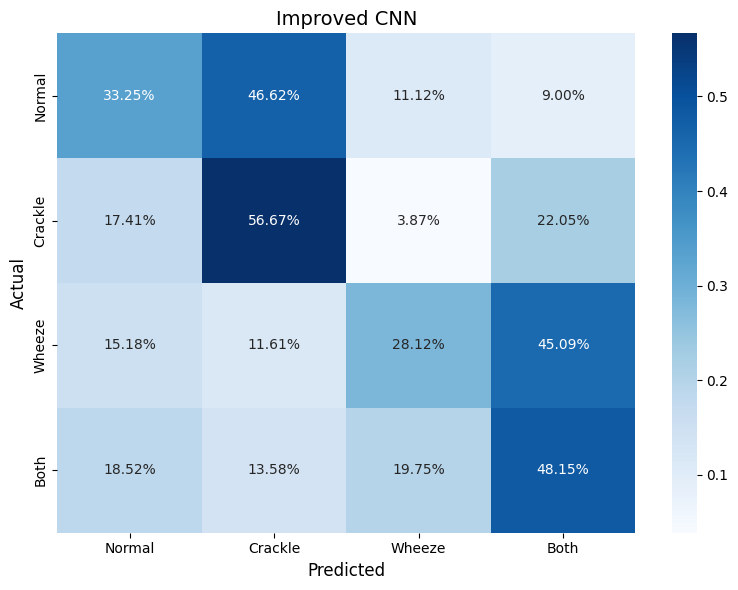

In [8]:
cnn_model.load_state_dict(torch.load(MODELS_DIR / "improved_cnn_best.pt", map_location=device))
plot_training_curves(cnn_history, title="Improved CNN", save_path=FIGURES_DIR / "improved_cnn_curves.png")

y_true_cnn, y_pred_cnn = [], []
cnn_model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = cnn_model(inputs)
        _, predicted = outputs.max(1)
        y_true_cnn.extend(labels.numpy())
        y_pred_cnn.extend(predicted.cpu().numpy())

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)

cnn_results = evaluate_predictions(y_true_cnn, y_pred_cnn, title="Improved CNN")
plot_confusion_matrix(y_true_cnn, y_pred_cnn, title="Improved CNN",
                      save_path=FIGURES_DIR / "cm_improved_cnn.png")

## 4.8 Improved CRNN (CNN + BiGRU + Attention)
Same CRNN architecture as before, but now benefits from:
- Normalised input spectrograms
- Audio-level augmentation
- Better training loop (mixup, lower LR, cosine annealing)

In [9]:
class ImprovedCRNN(nn.Module):
    def __init__(self, num_classes=4, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.15),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d((2, 1)), nn.Dropout2d(0.2),
        )

        self.cnn_freq_out = N_MELS // 16  # 128/16 = 8
        rnn_input = 256 * self.cnn_freq_out

        self.rnn = nn.GRU(
            input_size=rnn_input, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            bidirectional=True, dropout=dropout if num_layers > 1 else 0,
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64), nn.Tanh(), nn.Linear(64, 1),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        batch_size = x.size(0)
        cnn_out = self.cnn(x)
        _, c, f, t = cnn_out.shape
        cnn_out = cnn_out.permute(0, 3, 1, 2).reshape(batch_size, t, c * f)
        rnn_out, _ = self.rnn(cnn_out)
        attn = torch.softmax(self.attention(rnn_out), dim=1)
        context = torch.sum(rnn_out * attn, dim=1)
        return self.classifier(context)


crnn_model = ImprovedCRNN(num_classes=4).to(device)
print(f"Improved CRNN parameters: {sum(p.numel() for p in crnn_model.parameters()):,}")

# Quick shape check
with torch.no_grad():
    dummy = batch_specs[:2].to(device)
    out = crnn_model(dummy)
    print(f"Input: {dummy.shape} → Output: {out.shape}")

print("\n" + "=" * 60)
print("  Training Improved CRNN")
print("=" * 60)
crnn_history = train_improved(
    crnn_model, train_loader, val_loader,
    num_epochs=60, lr=3e-4, class_weights=class_weights,
    model_name="improved_crnn", patience=15, use_mixup=True
)

Improved CRNN parameters: 2,585,381
Input: torch.Size([2, 1, 128, 173]) → Output: torch.Size([2, 4])

  Training Improved CRNN
Epoch [  1/60] Train: 1.3814/0.3263  Val: 1.4050/0.2590  LR: 0.000300  ★ BEST
Epoch [  2/60] Train: 1.3679/0.3447  Val: 1.3823/0.3225  LR: 0.000299  ★ BEST
Epoch [  5/60] Train: 1.2537/0.3922  Val: 1.3463/0.4221  LR: 0.000295  ★ BEST
Epoch [  6/60] Train: 1.2070/0.3935  Val: 1.2466/0.4553  LR: 0.000293  ★ BEST
Epoch [  7/60] Train: 1.1690/0.4253  Val: 1.2428/0.4502  LR: 0.000290  ★ BEST
Epoch [  9/60] Train: 1.1084/0.4279  Val: 1.2357/0.4899  LR: 0.000284  ★ BEST
Epoch [ 10/60] Train: 1.0958/0.4382  Val: 1.2353/0.4986  LR: 0.000280  ★ BEST
Epoch [ 15/60] Train: 1.0299/0.4647  Val: 1.3030/0.4322  LR: 0.000256  
Epoch [ 20/60] Train: 0.9911/0.5125  Val: 1.2749/0.4993  LR: 0.000225  
Epoch [ 25/60] Train: 0.9370/0.5259  Val: 1.3497/0.5231  LR: 0.000189  

Early stopping at epoch 25

Best val loss: 1.2353, Best val acc: 0.4986


## 4.9 Evaluate Improved CRNN

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\improved_crnn_curves.png


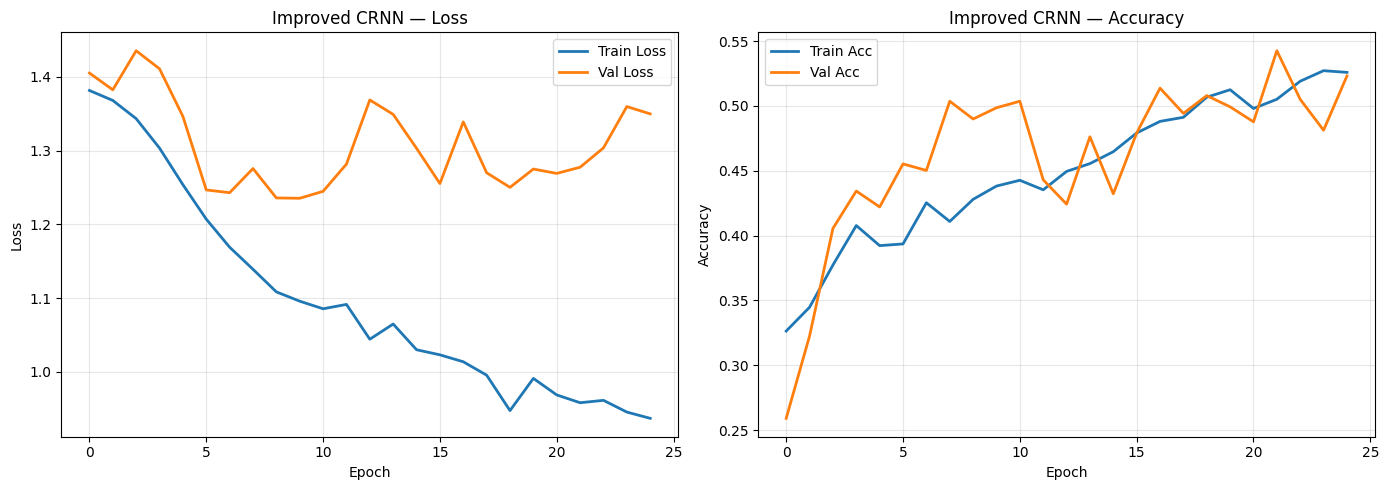


  Improved CRNN
  Accuracy:          0.3840
  F1 (macro):        0.3528
  F1 (weighted):     0.3861

              precision    recall  f1-score   support

      Normal       0.58      0.30      0.39       800
     Crackle       0.38      0.54      0.45       517
      Wheeze       0.25      0.34      0.29       224
        Both       0.23      0.36      0.28       162

    accuracy                           0.38      1703
   macro avg       0.36      0.38      0.35      1703
weighted avg       0.44      0.38      0.39      1703

  Saved: E:\GitHub\lung-sound-classification\outputs\figures\cm_improved_crnn.png


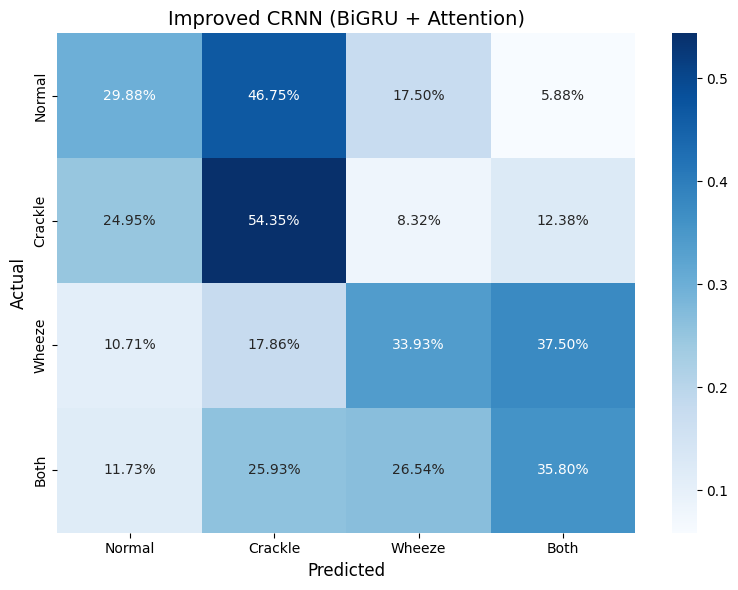

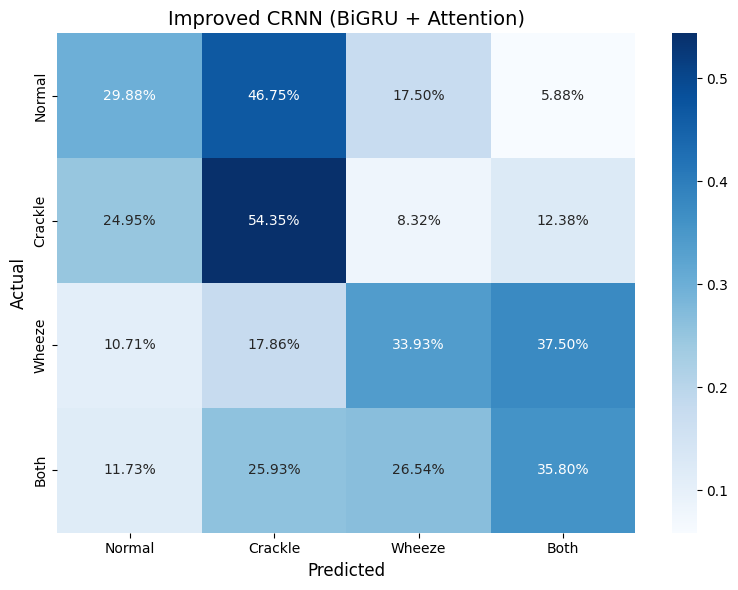

In [10]:
crnn_model.load_state_dict(torch.load(MODELS_DIR / "improved_crnn_best.pt", map_location=device))
plot_training_curves(crnn_history, title="Improved CRNN", save_path=FIGURES_DIR / "improved_crnn_curves.png")

y_true_crnn, y_pred_crnn = [], []
crnn_model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = crnn_model(inputs)
        _, predicted = outputs.max(1)
        y_true_crnn.extend(labels.numpy())
        y_pred_crnn.extend(predicted.cpu().numpy())

y_true_crnn = np.array(y_true_crnn)
y_pred_crnn = np.array(y_pred_crnn)

crnn_results = evaluate_predictions(y_true_crnn, y_pred_crnn, title="Improved CRNN")
plot_confusion_matrix(y_true_crnn, y_pred_crnn, title="Improved CRNN (BiGRU + Attention)",
                      save_path=FIGURES_DIR / "cm_improved_crnn.png")

## 4.10 Full Model Comparison
All models compared: ML baselines, original DL, and improved DL with normalisation + augmentation.

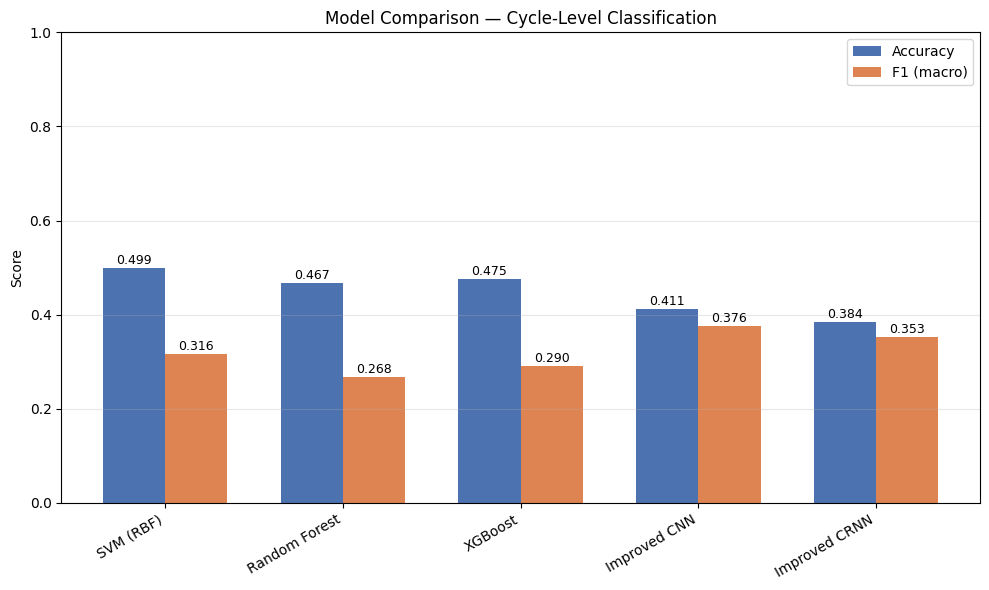


  FINAL RESULTS SUMMARY
Model                    Accuracy   F1 (macro)
----------------------------------------------
SVM (RBF)                  0.4990       0.3160
Random Forest              0.4670       0.2680
XGBoost                    0.4750       0.2900
Improved CNN               0.4110       0.3756
Improved CRNN              0.3840       0.3528


In [11]:
all_results = {
    "SVM (RBF)": {"accuracy": 0.499, "f1_macro": 0.316},
    "Random Forest": {"accuracy": 0.467, "f1_macro": 0.268},
    "XGBoost": {"accuracy": 0.475, "f1_macro": 0.290},
    "Improved CNN": cnn_results,
    "Improved CRNN": crnn_results,
}

compare_models(all_results, save_path=FIGURES_DIR / "final_model_comparison.png")

print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"{'Model':<22} {'Accuracy':>10} {'F1 (macro)':>12}")
print("-" * 46)
for name, res in all_results.items():
    print(f"{name:<22} {res['accuracy']:>10.4f} {res['f1_macro']:>12.4f}")